<a href="https://colab.research.google.com/github/kacp-i/BCU-Work/blob/main/Y4%20S1%20CMP6232%20Deep%20Neural%20Networks%20and%20Ethics/CMP6232_Deep_Neural_Networks_and_Ethics_Lab_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Activity 1 - Verify your setup

In [1]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.utils import to_categorical
import numpy as np

# Set random seed for reproducibility
np.random.seed(1671)

# Hyperparameters
NB_EPOCH = 20            # number of training epochs (increase to train longer)
BATCH_SIZE = 128         # samples per gradient update
VERBOSE = 1              # 1 = progress bar, 0 = silent, 2 = one line per epoch
NB_CLASSES = 10          # number of output classes (digits 0-9)
OPTIMIZER = SGD()        # Stochastic Gradient Descent optimiser
VALIDATION_SPLIT = 0.2   # fraction of training data used for validation
RESHAPED = 784           # 28 x 28 pixels = 784 features per sample

# Load and prepare the MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train.reshape(60000, RESHAPED).astype('float32') / 255
X_test  = X_test.reshape(10000, RESHAPED).astype('float32') / 255
print(X_train.shape[0], 'train samples')
print(X_test.shape[0], 'test samples')

# Convert class labels to one-hot encoded vectors
Y_train = to_categorical(y_train, NB_CLASSES)
Y_test  = to_categorical(y_test, NB_CLASSES)

# Build the neural network model
model = Sequential()
model.add(Dense(NB_CLASSES, input_shape=(RESHAPED,)))
model.add(Activation('softmax'))   # softmax for multi-class classification
model.summary()

# Compile and train
model.compile(loss='categorical_crossentropy', optimizer=OPTIMIZER, metrics=['accuracy'])
history = model.fit(X_train, Y_train,
                    batch_size=BATCH_SIZE, epochs=NB_EPOCH,
                    verbose=VERBOSE, validation_split=VALIDATION_SPLIT)

# Evaluate on the test set
score = model.evaluate(X_test, Y_test, verbose=VERBOSE)
print('Test score:', score[0])       # loss on the test set
print('Test accuracy:', score[1])    # accuracy on the test set

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
60000 train samples
10000 test samples


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │         7,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6809 - loss: 1.3586 - val_accuracy: 0.8282 - val_loss: 0.8904
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8284 - loss: 0.7891 - val_accuracy: 0.8558 - val_loss: 0.6556
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8493 - loss: 0.6414 - val_accuracy: 0.8676 - val_loss: 0.5609
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8604 - loss: 0.5698 - val_accuracy: 0.8749 - val_loss: 0.5083
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8678 - loss: 0.5262 - val_accuracy: 0.8811 - val_loss: 0.4744
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8737 - loss: 0.4961 - val_accuracy: 0.8852 - val_loss: 0.4503
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8774 - loss: 0.4738 - val_accuracy: 0.8878 - val_loss: 0.4321
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8800 - loss: 0.4565 - val_accuracy: 0.

# Activity 2 - Explore the Data

Training images: (60000, 28, 28)
Test images: (10000, 28, 28)
Classes: [0 1 2 3 4 5 6 7 8 9]


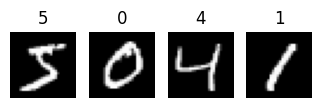

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 18

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()
print('Training images:', x_train.shape)   # (60000, 28, 28)
print('Test images:', x_test.shape)        # (10000, 28, 28)
print('Classes:', np.unique(y_train))      # digits 0-9

# Show the first 10 training images with their labels
plt.figure(figsize=(10, 2))
for i in range(4):
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(str(y_train[i]))
    plt.axis('off')
plt.show()
print(x_train[0])

## Questions

• How many training and test images are there? What is the shape of a single image?<br>
Training images = 60000<br>Test images = 10000<br>Shape is a square<br><br>

• Change the range in the loop to view different digits.<br>
Changed to 20, gives an error. Cant go above 10 as there are no more digits. Changed to 6 gives numbers 504192. Changed to 4 gives 5041<br><br>

• Add print(x_train[0]) to see the raw pixel values behind one image.<br>Shows the pixel value of the digit 5

# Activity 3 - Improve the Model

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers import SGD

# Reuses X_train, Y_train, X_test, Y_test, RESHAPED, NB_CLASSES,
# BATCH_SIZE, NB_EPOCH and VALIDATION_SPLIT from Activity 1.
N_HIDDEN = 256

model = Sequential()
model.add(Dense(N_HIDDEN, input_shape=(RESHAPED,), activation='relu'))  # hidden layer
model.add(Dropout(0.3))                                                 # reduces overfitting
model.add(Dense(NB_CLASSES, activation='softmax'))                      # output layer
model.summary()

model.compile(loss='categorical_crossentropy', optimizer=SGD(), metrics=['accuracy'])
history = model.fit(X_train, Y_train,
                    batch_size=BATCH_SIZE, epochs=NB_EPOCH,
                    verbose=VERBOSE, validation_split=VALIDATION_SPLIT)

score = model.evaluate(X_test, Y_test, verbose=VERBOSE)
print('Test accuracy:', score[1])

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_19 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6506 - loss: 1.3022 - val_accuracy: 0.8535 - val_loss: 0.7065
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8239 - loss: 0.6732 - val_accuracy: 0.8842 - val_loss: 0.4876
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8531 - loss: 0.5365 - val_accuracy: 0.8986 - val_loss: 0.4103
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8669 - loss: 0.4732 - val_accuracy: 0.9053 - val_loss: 0.3693
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8774 - loss: 0.4332 - val_accuracy: 0.9115 - val_loss: 0.3435
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8865 - loss: 0.4041 - val_accuracy: 0.9147 - val_loss: 0.3239
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8922 - loss: 0.3845 - val_accuracy: 0.9180 - val_loss: 0.3091
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8973 - loss: 0.3664 - val_accuracy: 0.

## Questions

• Compare the test accuracy with Activity 1. How much did it improve?<br>
Activity 1 accuracy is 91%, Activity 3 accuracy is 98%<br><br>

• Change N_HIDDEN (for example 64 or 256) and re-run. What happens?<br>
Changed to 64, Acuraccy seems to have decreased to 97%.<br>
Changed to 256, Accuracy seems to have increased to 98.2%<br>
Increasing the N_Hidden upps the accuarcy, but by a small amount, increasing too much may not benefit a lot<br>

• Swap the optimiser back to SGD() and compare it with Adam().<br>
N_Hidden = 128 on Adam = 98%<br>
N_Hidden = 256 on Adam = 98.2%<br>
N_Hidden = 128 on SGD = 93.6%<br>
N_Hidden = 256 on SGD = 93.9%<br>